### 馬達論文研究
### 第五步 重新模型建立
### 馬達C 6000RPM
### CNN_Res
### 10種工況

In [1]:
# 匯入所需函式庫
import os
import logging
import absl.logging
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, label_binarize, LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Concatenate, Add, Activation, GlobalAveragePooling1D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'{screws}\\T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [3]:
# 新資料
def load_and_preprocess_newdata(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, f'{screws}\\T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [4]:
# 加載資料
rootDir = os.getcwd()
myfeatureDirectory = f'{rootDir}\\階段1\\myfeature\\T1\\6000rpm'

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T1 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [5]:
myfeatureDirectory2 = f'{rootDir}\\階段1\\myfeature\\T1\\6000rpm'

screws_list2 = ['5screws', '6screws', '7screws', '3_14screws', '4_146screws']
datasets_T2 = load_and_preprocess_newdata(myfeatureDirectory2, screws_list2)

In [6]:
# 合併資料
combined_data = pd.concat(datasets_T1 + datasets_T2, ignore_index=True)

In [7]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws', '5screws', '6screws', '7screws', '3_14screws', '4_146screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [8]:
# 標籤編碼
le_screws = LabelEncoder()
combined_data['screws'] = le_screws.fit_transform(combined_data['screws'])

In [9]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

自訂 Label Mapping:
8screws: 0
1screws: 1
2screws: 2
3screws: 3
4screws: 4
5screws: 5
6screws: 6
7screws: 7
3_14screws: 8
4_146screws: 9


In [10]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [11]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42
)

In [12]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# ResNet 殘差模塊
def res_block(X_input, filters, stride=1):
    shortcut = X_input

    # 主分支 - Conv1
    X = Conv1D(filters, kernel_size=3, strides=stride, padding='same')(X_input)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)

    # 主分支 - Conv2
    X = Conv1D(filters, kernel_size=3, strides=1, padding='same')(X)
    X = BatchNormalization()(X)

    # 如果維度不一致則使用 Conv1D 處理 shortcut
    if X_input.shape[-1] != filters or stride != 1:
        shortcut = Conv1D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # 殘差連接
    X = Add()([X, shortcut])
    X = Activation('relu')(X)
    return X

In [14]:
# 建立 ResNet 模型
def build_resnet_model(input_shape, num_classes):
    # 輸入層
    X_input = Input(shape=input_shape)

    # 初始卷積層（第 1 層）
    X = Conv1D(32, kernel_size=7, strides=2, padding='same')(X_input)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)
    X = MaxPooling1D(pool_size=3, strides=2, padding='same')(X)

    # conv2_x: 2 個 basic blocks（第 2~5 層）
    X = res_block(X, filters=32, stride=1)
    X = res_block(X, filters=32, stride=1)

    # conv3_x: 2 個 basic blocks（第 6~9 層）
    X = res_block(X, filters=32, stride=2)
    X = res_block(X, filters=32, stride=1)

    # conv4_x: 2 個 basic blocks（第 10~13 層）
    X = res_block(X, filters=64, stride=2)
    X = res_block(X, filters=64, stride=1)

    # conv5_x: 2 個 basic blocks（第 14~17 層）
    X = res_block(X, filters=128, stride=2)
    X = res_block(X, filters=128, stride=1)

    # GlobalAveragePooling + Dense（第 18 層）
    X = GlobalAveragePooling1D()(X)
    output = Dense(num_classes, activation='softmax', name="Screw_Number_Output")(X)

    # 定義模型
    model = Model(inputs=X_input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [15]:
# 模型參數
num_screw_classes = len(np.unique(y_train_screws))

In [16]:
# 建立與訓練模型
ResNet_model = build_resnet_model((X_train.shape[1], 1), num_screw_classes)
history = ResNet_model.fit(
    X_train.reshape(X_train.shape[0], X_train.shape[1], 1),
    y_train_screws,
    validation_data=(
        X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
        y_test_screws
    ),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.5674 - loss: 1.4890 - val_accuracy: 0.1303 - val_loss: 2.3477
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9966 - loss: 0.0611 - val_accuracy: 0.8832 - val_loss: 0.4622
Epoch 3/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9994 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 4/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9999 - loss: 0.0106 - val_accuracy: 0.9992 - val_loss: 0.0038
Epoch 5/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 0.0029 -

In [17]:
# 模型架構
ResNet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 105, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 53, 32)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 53, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 53, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 27, 32)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 27, 32)    │      3,104 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 27, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 27, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 27, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 27, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 27, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 771,264 (2.94 MB)

 Trainable params: 256,234 (1000.91 KB)

 Non-trainable params: 2,560 (10.00 KB)

 Optimizer params: 512,470 (1.95 MB)

In [18]:
# 評估模型
results = ResNet_model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Screw Number Loss: {results[0]:.4f}, Screw Number Accuracy: {results[1]:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.3123e-06
Screw Number Loss: 0.0000, Screw Number Accuracy: 1.0000


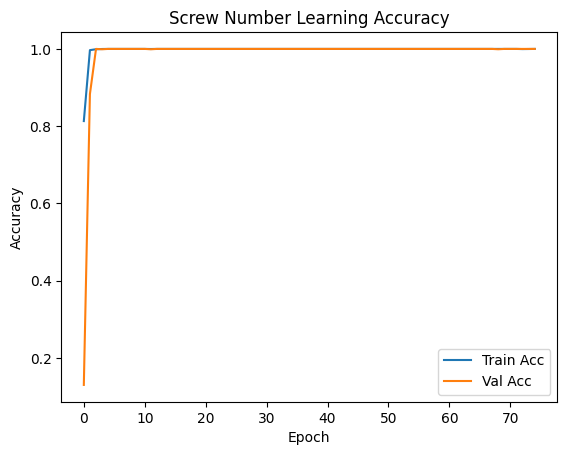

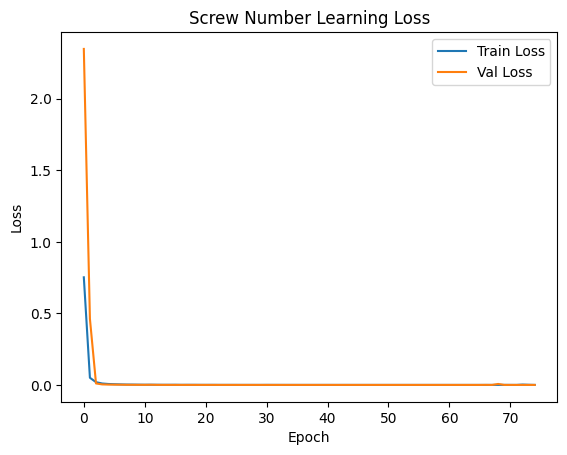

In [19]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Screw Number Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Screw Number Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step


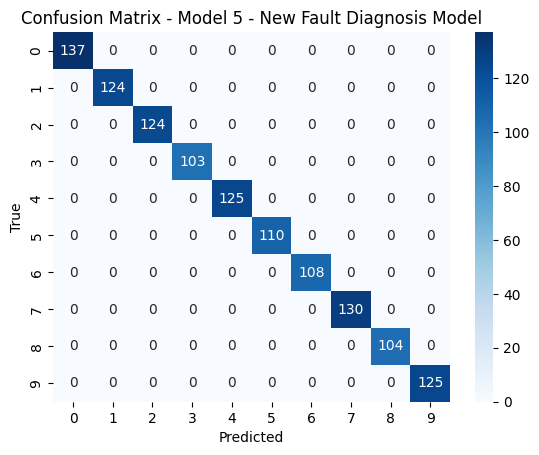

In [20]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    numeric_labels = range(len(label_encoder.classes_))  # 使用數字標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=numeric_labels, yticklabels=numeric_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = ResNet_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, le_screws, "Confusion Matrix - Model 5 - New Fault Diagnosis Model")